# 08 — Regresja liniowa: od prostej do $R^2$, testu $F$ i overfittingu

Ten notebook jest przygotowany jako **pełny, prosty wykład** do bloku *Linear models*: najpierw bardzo intuicyjnie patrzymy na punkty, prostą i kwadraty błędów, a dopiero potem formalizujemy metryki.

Łączymy cztery perspektywy:

1. **Intuicję geometryczną**: punkty, prosta, pionowe błędy, minimum funkcji błędu.
2. **Perspektywę statystyczną**: baseline średniej, rozkład zmienności, $R^2$, adjusted $R^2$, test $F$.
3. **Perspektywę ML**: `fit`, `predict`, train/test, cross-validation, generalizacja.
4. **Perspektywę dydaktyczną**: ręczne liczenie małych przykładów i zadanie w GeoGebrze.

Motyw przewodni wykładu:

> Regresja liniowa nie szuka prostej, która „ładnie wygląda”. Szuka parametrów, które minimalizują jasno zdefiniowaną funkcję straty. Potem sprawdzamy, czy ta prosta faktycznie pomaga lepiej przewidywać niż średnia.


## Cele dla studentów

Po zajęciach student powinien umieć:

- odróżnić **regresję** od klasyfikacji,
- zapisać model $\hat y = b_0 + b_1x$ i zinterpretować $b_0$, $b_1$,
- wyjaśnić, co robi metoda `.fit()` w modelu regresji,
- policzyć predykcje, reszty i SSE dla danej prostej,
- porównać model z baseline’em przewidującym średnią,
- policzyć i zinterpretować $\mathrm{TSS}$, $\mathrm{SSR}$, $\mathrm{SSE}$ oraz $R^2$,
- policzyć adjusted $R^2$ i wyjaśnić, po co karze liczbę cech,
- policzyć statystykę $F$ dla całego modelu i zrozumieć, co testuje,
- odróżnić **dobry fit** od **underfittingu** i **overfittingu**,
- rozumieć, dlaczego wynik treningowy nie wystarcza,
- rozpoznać typowe problemy: outlier, nieliniowość, ekstrapolacja, dodawanie przypadkowych cech.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.set_printoptions(precision=3, suppress=True)


## 1. Problem: przewidujemy liczbę ciągłą

W klasyfikacji przewidujemy etykietę, np. `spam / nie spam` albo `0 / 1`.

W regresji przewidujemy **liczbę ciągłą**, np. cenę, temperaturę, czas, rozmiar, wynik pomiaru.

W tym przykładzie:

$$x = \text{weight}$$

$$y = \text{size}$$

czyli pytamy:

> Czy na podstawie masy można przewidywać rozmiar?

Ważne: regresja liniowa może być używana zarówno do **predykcji**, jak i do **opisu zależności**. W ML bardziej interesuje nas predykcja na nowych danych. W statystyce często bardziej interesuje nas interpretacja współczynników i niepewność estymacji.


In [6]:
# Mały dataset w stylu StatQuest: weight -> size.
# Celowo jest mały, żeby można było ręcznie policzyć pierwsze błędy.
mouse = pd.DataFrame({
    "weight": [0.9, 1.8, 2.4, 3.5, 3.9, 4.4, 5.1, 5.6, 6.3],
    "size":   [1.4, 2.6, 1.0, 3.7, 5.5, 3.2, 3.0, 4.9, 6.3],
})
mouse


,weight,size
0,0.9,1.4
1,1.8,2.6
2,2.4,1.0
3,3.5,3.7
4,3.9,5.5
5,4.4,3.2
6,5.1,3.0
7,5.6,4.9
8,6.3,6.3


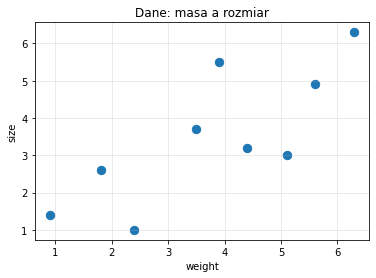

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter(mouse["weight"], mouse["size"], s=70)
plt.xlabel("weight")
plt.ylabel("size")
plt.title("Dane: masa a rozmiar")
plt.grid(alpha=0.3)
plt.show()


## 2. Zanim pojawi się model: baseline przewidujący średnią

Bardzo dobry nawyk ML:

> Zanim ocenimy model, sprawdźmy prosty baseline.

Najprostszy model regresyjny przewiduje zawsze średnią wartość $y$:

$$\hat y = \bar y$$

Taki model ignoruje $x$. Jeśli regresja liniowa nie pokona tego baseline’u, to znaczy, że cecha `weight` niewiele pomaga.


In [8]:
y_mean = mouse["size"].mean()
mouse_baseline = mouse.copy()
mouse_baseline["mean_prediction"] = y_mean
mouse_baseline["mean_residual"] = mouse_baseline["size"] - mouse_baseline["mean_prediction"]
mouse_baseline["mean_squared_error"] = mouse_baseline["mean_residual"] ** 2

print(f"Średnia wartość size = {y_mean:.3f}")
print(f"SSE baseline'u średniej = {mouse_baseline['mean_squared_error'].sum():.3f}")
mouse_baseline


Średnia wartość size = 3.511
SSE baseline'u średniej = 25.649


,weight,size,mean_prediction,mean_residual,mean_squared_error
0,0.9,1.4,3.511111,-2.111111,4.456790
1,1.8,2.6,3.511111,-0.911111,0.830123
2,2.4,1.0,3.511111,-2.511111,6.305679
3,3.5,3.7,3.511111,0.188889,0.035679
4,3.9,5.5,3.511111,1.988889,3.955679
5,4.4,3.2,3.511111,-0.311111,0.096790
6,5.1,3.0,3.511111,-0.511111,0.261235
7,5.6,4.9,3.511111,1.388889,1.929012
8,6.3,6.3,3.511111,2.788889,7.777901


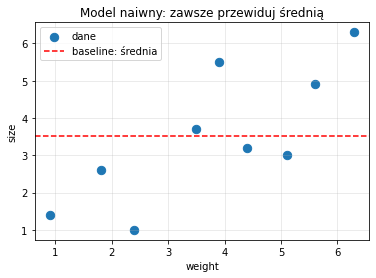

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(mouse["weight"], mouse["size"], s=70, label="dane")
plt.axhline(y_mean, linestyle="--", label="baseline: średnia",color="red")
plt.xlabel("weight")
plt.ylabel("size")
plt.title("Model naiwny: zawsze przewiduj średnią")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. Model liniowy  - zrobić przypomnienie w Geogebra 

Najprostszy model liniowy dla jednej cechy ma postać:

$$\hat y = b_0 + b_1x$$

gdzie:

- $b_0$ — intercept, czyli punkt przecięcia z osią $y$,
- $b_1$ — slope, czyli nachylenie prostej,
- $\hat y$ — predykcja modelu.

Interpretacja $b_1$:

> Jeśli $x$ wzrośnie o 1 jednostkę, model przewiduje średnią zmianę $y$ o $b_1$ jednostki.

Uwaga dydaktyczna: intercept $b_0$ bywa matematycznie potrzebny, ale nie zawsze ma sens praktyczny. W przykładzie z myszami predykcja dla `weight = 0` może być poza sensownym zakresem danych.


## 4. Co właściwie minimalizujemy?

Dla punktu $(x_i, y_i)$ model daje predykcję:

$$\hat y_i = b_0 + b_1x_i$$

Reszta, czyli błąd pionowy, to:

$$e_i = y_i - \hat y_i$$

Regresja liniowa metodą najmniejszych kwadratów (**SSE - Sum of Squared Errors/Sum of Squared Residuals/RSS — Residual Sum of Squares**) minimalizuje:

$$\mathrm{SSE} = \sum_{i=1}^{n}(y_i - \hat y_i)^2$$

czyli:

$$\mathrm{SSE}(b_0,b_1)=\sum_{i=1}^{n}(y_i - (b_0+b_1x_i))^2$$

Dlaczego kwadraty?

- błędy dodatnie i ujemne nie kasują się,
- większe błędy są karane mocniej,
- funkcja jest gładka i ma wygodne minimum,
- przy założeniu szumu normalnego metoda najmniejszych kwadratów ma naturalną interpretację probabilistyczną.


In [11]:
def sse_for_line(slope, intercept, x, y):
    y_hat = intercept + slope * np.asarray(x)
    return np.sum((np.asarray(y) - y_hat) ** 2)

candidate_lines = pd.DataFrame({
    "model": ["za płaska", "na oko", "za stroma", "blisko dobrej"],
    "slope_b1": [0.30, 0.70, 1.20, 0.86],
    "intercept_b0": [2.00, 0.90, -1.00, 0.50],
})

candidate_lines["SSE"] = [
    sse_for_line(row.slope_b1, row.intercept_b0, mouse["weight"], mouse["size"])
    for row in candidate_lines.itertuples()
]

candidate_lines.sort_values("SSE")


,model,slope_b1,intercept_b0,SSE
1,na oko,0.70,0.9,10.082100
3,blisko dobrej,0.86,0.5,10.563124
2,za stroma,1.20,-1.0,14.553600
0,za płaska,0.30,2.0,17.162100


In [12]:
# Funkcja licząca SSE (Sum of Squared Errors)
# dla zadanej prostej:
#
# y_hat = intercept + slope * x
#
# SSE = suma (y - y_hat)^2
#
# Im mniejsze SSE, tym lepiej prosta pasuje do danych.

def sse_for_line(slope, intercept, x, y):

    # Predykcje modelu liniowego:
    #
    # y_hat = b0 + b1 * x
    #
    # intercept -> b0
    # slope     -> b1
    #
    y_hat = intercept + slope * np.asarray(x)

    # Liczymy:
    #
    # SSE = suma kwadratów błędów
    #
    # (y - y_hat)^2
    #
    return np.sum((np.asarray(y) - y_hat) ** 2)


# Kilka ręcznie wybranych prostych.
#
# Chcemy porównać,
# która daje najmniejszy błąd.
#
candidate_lines = pd.DataFrame({

    # Opis słowny modelu
    "model": [
        "za płaska",
        "na oko",
        "za stroma",
        "blisko dobrej"
    ],

    # Nachylenie prostej (b1)
    "slope_b1": [
        0.30,
        0.70,
        1.20,
        0.86
    ],

    # Intercept (b0)
    "intercept_b0": [
        2.00,
        0.90,
        -1.00,
        0.50
    ],
})


# Dla każdej prostej liczymy SSE.
#
# Im mniejsze SSE,
# tym lepiej model pasuje do danych.
#
candidate_lines["SSE"] = [

    sse_for_line(
        row.slope_b1,
        row.intercept_b0,
        mouse["weight"],
        mouse["size"]
    )

    for row in candidate_lines.itertuples()
]


# Sortujemy modele od najlepszego
# (najmniejsze SSE)
# do najgorszego.
#
candidate_lines.sort_values("SSE")

,model,slope_b1,intercept_b0,SSE
1,na oko,0.70,0.9,10.082100
3,blisko dobrej,0.86,0.5,10.563124
2,za stroma,1.20,-1.0,14.553600
0,za płaska,0.30,2.0,17.162100


In [14]:
x_grid = np.linspace(mouse["weight"].min() - 0.5, mouse["weight"].max() + 0.5, 200)
x_grid

array([0.4  , 0.432, 0.464, 0.496, 0.529, 0.561, 0.593, 0.625, 0.657,
       0.689, 0.722, 0.754, 0.786, 0.818, 0.85 , 0.882, 0.915, 0.947,
       0.979, 1.011, 1.043, 1.075, 1.108, 1.14 , 1.172, 1.204, 1.236,
       1.268, 1.301, 1.333, 1.365, 1.397, 1.429, 1.461, 1.493, 1.526,
       1.558, 1.59 , 1.622, 1.654, 1.686, 1.719, 1.751, 1.783, 1.815,
       1.847, 1.879, 1.912, 1.944, 1.976, 2.008, 2.04 , 2.072, 2.105,
       2.137, 2.169, 2.201, 2.233, 2.265, 2.297, 2.33 , 2.362, 2.394,
       2.426, 2.458, 2.49 , 2.523, 2.555, 2.587, 2.619, 2.651, 2.683,
       2.716, 2.748, 2.78 , 2.812, 2.844, 2.876, 2.909, 2.941, 2.973,
       3.005, 3.037, 3.069, 3.102, 3.134, 3.166, 3.198, 3.23 , 3.262,
       3.294, 3.327, 3.359, 3.391, 3.423, 3.455, 3.487, 3.52 , 3.552,
       3.584, 3.616, 3.648, 3.68 , 3.713, 3.745, 3.777, 3.809, 3.841,
       3.873, 3.906, 3.938, 3.97 , 4.002, 4.034, 4.066, 4.098, 4.131,
       4.163, 4.195, 4.227, 4.259, 4.291, 4.324, 4.356, 4.388, 4.42 ,
       4.452, 4.484,

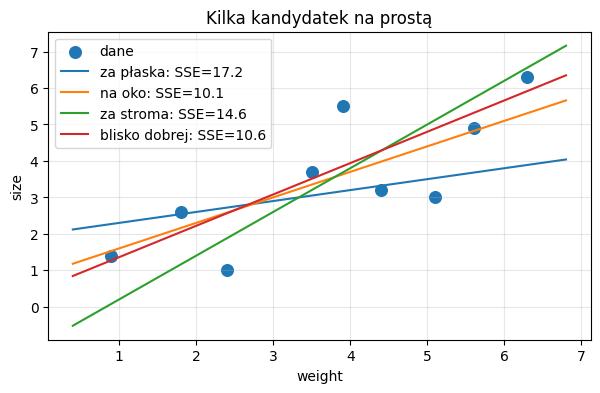

In [7]:
x_grid = np.linspace(mouse["weight"].min() - 0.5, mouse["weight"].max() + 0.5, 200)

plt.figure(figsize=(7, 4))
plt.scatter(mouse["weight"], mouse["size"], s=70, label="dane")

for row in candidate_lines.itertuples():
    y_grid = row.intercept_b0 + row.slope_b1 * x_grid
    plt.plot(x_grid, y_grid, label=f"{row.model}: SSE={row.SSE:.1f}")

plt.xlabel("weight")
plt.ylabel("size")
plt.title("Kilka kandydatek na prostą")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 5. Dopasowanie modelu w scikit-learn

W `scikit-learn` standardowy schemat wygląda tak:

```python
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X_new)
```

Ważne: `X` musi być macierzą 2D, nawet jeśli mamy tylko jedną cechę.


In [8]:
X = mouse[["weight"]]
y = mouse["size"]

lin = LinearRegression()
lin.fit(X, y)

print(f"b1 / slope     = {lin.coef_[0]:.6f}")
print(f"b0 / intercept = {lin.intercept_:.6f}")


b1 / slope     = 0.777821
b0 / intercept = 0.581321


In [9]:
y_pred = lin.predict(X)
mouse_fit = mouse.copy()
mouse_fit["prediction"] = y_pred
mouse_fit["residual"] = mouse_fit["size"] - mouse_fit["prediction"]
mouse_fit["squared_residual"] = mouse_fit["residual"] ** 2
mouse_fit


,weight,size,prediction,residual,squared_residual
0,0.9,1.4,1.281359,0.118641,0.014076
1,1.8,2.6,1.981397,0.618603,0.382669
2,2.4,1.0,2.448090,-1.448090,2.096964
3,3.5,3.7,3.303692,0.396308,0.157060
4,3.9,5.5,3.614821,1.885179,3.553902
5,4.4,3.2,4.003731,-0.803731,0.645983
6,5.1,3.0,4.548205,-1.548205,2.396939
7,5.6,4.9,4.937115,-0.037115,0.001378
8,6.3,6.3,5.481590,0.818410,0.669795


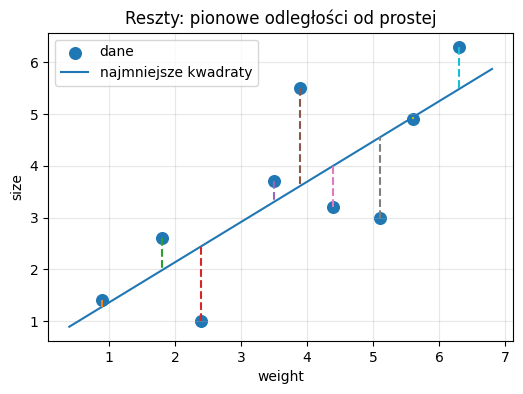

In [10]:
x_grid_2d = x_grid.reshape(-1, 1)
y_grid_pred = lin.predict(pd.DataFrame({"weight": x_grid}))

plt.figure(figsize=(6, 4))
plt.scatter(mouse["weight"], mouse["size"], s=70, label="dane")
plt.plot(x_grid, y_grid_pred, label="najmniejsze kwadraty")

for row in mouse_fit.itertuples():
    plt.plot([row.weight, row.weight], [row.size, row.prediction], linestyle="--")

plt.xlabel("weight")
plt.ylabel("size")
plt.title("Reszty: pionowe odległości od prostej")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 6. Ręczna formuła dla prostej

Dla jednej cechy można policzyć parametry bez `sklearn`:

$$b_1 = \frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sum_i (x_i-\bar x)^2}$$

$$b_0 = \bar y - b_1\bar x$$

To pokazuje ważną intuicję:

- nachylenie zależy od współzmienności $x$ i $y$,
- jeśli $x$ i $y$ rosną razem, slope będzie dodatni,
- jeśli $x$ rośnie, a $y$ maleje, slope będzie ujemny.


In [11]:
x = mouse["weight"].to_numpy()
y_arr = mouse["size"].to_numpy()

x_bar = x.mean()
y_bar = y_arr.mean()

b1_manual = np.sum((x - x_bar) * (y_arr - y_bar)) / np.sum((x - x_bar) ** 2)
b0_manual = y_bar - b1_manual * x_bar

print(f"Ręcznie b1 = {b1_manual:.6f}")
print(f"Ręcznie b0 = {b0_manual:.6f}")
print()
print(f"sklearn b1 = {lin.coef_[0]:.6f}")
print(f"sklearn b0 = {lin.intercept_:.6f}")


Ręcznie b1 = 0.777821
Ręcznie b0 = 0.581321

sklearn b1 = 0.777821
sklearn b0 = 0.581321


## 7. Geometryczna intuicja: powierzchnia błędu

Dla każdej pary parametrów $(b_1, b_0)$ możemy policzyć SSE.

To oznacza, że uczenie regresji liniowej jest szukaniem najniższego punktu na powierzchni:

$$ (b_1,b_0) \mapsto \mathrm{SSE}(b_1,b_0) $$

W jednej cesze możemy tę powierzchnię zobaczyć jako mapę konturową. W wielu cechach dzieje się to samo, tylko w większej liczbie wymiarów.


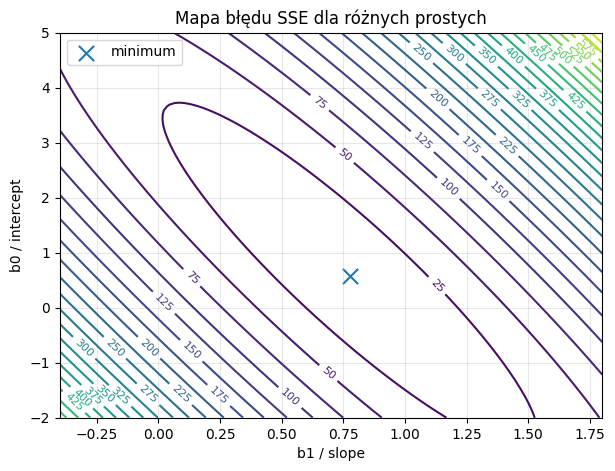

In [12]:
b1_values = np.linspace(-0.4, 1.8, 100)
b0_values = np.linspace(-2.0, 5.0, 100)
B1, B0 = np.meshgrid(b1_values, b0_values)
SSE = np.zeros_like(B1)

for i in range(B1.shape[0]):
    for j in range(B1.shape[1]):
        SSE[i, j] = sse_for_line(B1[i, j], B0[i, j], x, y_arr)

plt.figure(figsize=(7, 5))
cs = plt.contour(B1, B0, SSE, levels=28)
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter([lin.coef_[0]], [lin.intercept_], s=120, marker="x", label="minimum")
plt.xlabel("b1 / slope")
plt.ylabel("b0 / intercept")
plt.title("Mapa błędu SSE dla różnych prostych")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 8. Metryki regresji: błąd w jednostkach i wynik względem średniej

Dla regresji nie używamy accuracy, bo nie ma klas. Najczęstsze metryki:

### MAE

$$\mathrm{MAE}=\frac{1}{n}\sum_i |y_i-\hat y_i|$$

Średni błąd w jednostkach zmiennej $y$. Łatwy do interpretacji.

### MSE

$$\mathrm{MSE}=\frac{1}{n}\sum_i(y_i-\hat y_i)^2$$

Średni kwadrat błędu. Mocniej karze duże pomyłki.

### RMSE

$$\mathrm{RMSE}=\sqrt{\mathrm{MSE}}$$

Wraca do jednostek $y$, ale nadal mocniej reaguje na duże błędy niż MAE.

### $R^2$

$$R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}$$

Najprostsza interpretacja ML-owa:

> $R^2$ mówi, jak bardzo model poprawia się względem baseline’u przewidującego średnią.

Interpretacja statystyczna:

> $R^2$ to proporcja zmienności $y$, którą model redukuje względem modelu stałego $\hat y=\bar y$.

Uwaga wykładowa:

- $R^2=1$ oznacza idealne predykcje.
- $R^2=0$ oznacza poziom baseline’u przewidującego średnią.
- $R^2<0$ na danych testowych oznacza, że model jest gorszy od baseline’u średniej policzonej na tych danych.
- Wysokie treningowe $R^2$ nie gwarantuje dobrej generalizacji.


In [13]:
def regression_report(y_true, y_pred, label="model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({
        "model": label,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
    })

baseline_pred = np.repeat(y.mean(), len(y))
metrics = pd.DataFrame([
    regression_report(y, baseline_pred, "baseline: średnia"),
    regression_report(y, y_pred, "linear regression"),
])
metrics

,model,MAE,MSE,RMSE,R2
0,baseline: średnia,1.412346,2.849877,1.688158,0.000000
1,linear regression,0.852698,1.102085,1.049802,0.613287


## 9. Dokładne liczenie $R^2$: TSS, RSS i ESS

Warto pokazać studentom $R^2$ nie jako „magiczną metrykę z biblioteki”, tylko jako porównanie dwóch modeli:

1. **Model zerowy / baseline**:

$$
\hat y_i = \bar y
$$

2. **Regresja liniowa**:

$$
\hat y_i = b_0 + b_1x_i
$$

---

### Całkowita suma kwadratów — TSS / SST

$$
TSS=\sum_i(y_i-\bar y)^2
$$

To jest całkowita zmienność danych względem średniej.

Innymi słowy:

> jak dużo błędu mamy, gdy ignorujemy $x$ i przewidujemy wszystkim obserwacjom średnią.

---

### Suma kwadratów reszt — RSS / SSE

$$
RSS=\sum_i(y_i-\hat y_i)^2
$$

To jest błąd, który został po dopasowaniu modelu.

Inaczej:

> ile zmienności model nadal nie umie wyjaśnić.

---

### Wyjaśniona suma kwadratów — ESS

$$
ESS=\sum_i(\hat y_i-\bar y)^2
$$

To jest część zmienności, którą model wyjaśnił.

Inaczej:

> ile „chaosu” model przesunął z błędu baseline’u do sensownych predykcji.

---

Dla klasycznej regresji liniowej z interceptem, liczonej na tych samych danych, zachodzi:

$$
TSS = ESS + RSS
$$

Stąd:

$$
R^2 = \frac{ESS}{TSS}
$$

oraz równoważnie:

$$
R^2 = 1 - \frac{RSS}{TSS}
$$

Najprostsza narracja:

> Najpierw mierzymy, jak źle jest, gdy przewidujemy tylko średnią. Potem mierzymy, ile błędu zostało po użyciu regresji. $R^2$ mówi, jaką część całkowitej zmienności model wyjaśnił.

Dobra intuicja słowna dla studentów

Możesz mówić tak:

TSS → „ile chaosu było w danych”

RSS → „ile chaosu zostało”

ESS → „ile chaosu model wyjaśnił”

Najlepsza intuicja:

> $R^2$ mówi, jaka część całkowitej zmienności danych została wyjaśniona przez model.

Formalnie:

$$
R^2 = \frac{ESS}{TSS}
$$

lub równoważnie:

$$
R^2 = 1 - \frac{RSS}{TSS}
$$

gdzie:

- $TSS$ — całkowita zmienność danych,
- $RSS$ — niewyjaśniony błąd modelu,
- $ESS$ — zmienność wyjaśniona przez model.

---

## Intuicja „chaosu”

Można to interpretować tak:

- $TSS$ = ile całkowitego „chaosu” było w danych,
- $RSS$ = ile chaosu zostało po modelu,
- $ESS$ = ile chaosu model wyjaśnił.

A więc:

$$
R^2
=
\frac{\text{wyjaśniony chaos}}{\text{całkowity chaos}}
$$

---

Nie mówimy więc:

> „ile błędy danych tłumaczą błędów modelu”

bo miesza to role poszczególnych wielkości.

Lepsza interpretacja:

> „ile całkowitej zmienności danych model potrafił wyjaśnić”

albo prościej:

> „jak dużo lepszy od przewidywania samej średniej jest model”.

---

## Intuicja baseline’u

Jeśli model przewiduje tylko średnią:

$$
\hat y_i = \bar y
$$

to:

$$
R^2 = 0
$$

bo model niczego nie wyjaśnia.

Jeśli model idealnie trafia:

$$
RSS = 0
$$

to:

$$
R^2 = 1
$$

czyli model wyjaśnia całą zmienność danych.

## Krótki most do odds: skąd bierze się $\frac{R^2}{1-R^2}$?

W zapisie testu $F$ przez $R^2$ pojawia się wyrażenie:

$$
\frac{R^2}{1-R^2}
$$

To nie jest odds ratio, ale jest bardzo podobne do zwykłych odds:

$$
\frac{p}{1-p}
$$

W obu przypadkach mamy schemat:

$$
\frac{x}{1-x}
$$

czyli:

> część interesująca względem pozostałej części.

---

Dla prawdopodobieństwa:

$$
\frac{p}{1-p}
$$

oznacza:

$$
\frac{\text{sukces}}
{\text{porażka}}
$$

czyli odds.

Dla regresji liniowej:

$$
\frac{R^2}{1-R^2}
$$

oznacza:

$$
\frac{\text{wyjaśniona zmienność}}
{\text{niewyjaśniona zmienność}}
$$

czyli:

> ile sygnału model wyjaśnia względem błędu, który nadal pozostał.

---

Ponieważ:

$$
R^2=\frac{ESS}{TSS}
$$

oraz:

$$
1-R^2=\frac{RSS}{TSS}
$$

to:

$$
\frac{R^2}{1-R^2}
=
\frac{ESS/TSS}{RSS/TSS}
=
\frac{ESS}{RSS}
$$

Czyli:

$$
\frac{R^2}{1-R^2}
$$

jest ilorazem:

> wyjaśniona struktura / niewyjaśniony chaos.

---

Przykład:

Jeśli:

$$
R^2=0.8
$$

to:

$$
1-R^2=0.2
$$

więc:

$$
\frac{R^2}{1-R^2}
=
\frac{0.8}{0.2}
=
4
$$

Interpretacja:

> model wyjaśnia cztery razy więcej zmienności, niż pozostawia niewyjaśnionego błędu.

In [14]:
def sums_of_squares(y_true, y_hat):
    y_true = np.asarray(y_true)
    y_hat = np.asarray(y_hat)
    y_bar = y_true.mean()

    tss = np.sum((y_true - y_bar) ** 2)
    sse = np.sum((y_true - y_hat) ** 2)
    ssr = np.sum((y_hat - y_bar) ** 2)
    r2 = 1 - sse / tss

    return {
        "TSS_total_variation": tss,
        "SSR_explained_variation": ssr,
        "SSE_unexplained_error": sse,
        "R2_1_minus_SSE_over_TSS": r2,
        "R2_SSR_over_TSS": ssr / tss,
    }

ss = sums_of_squares(y_arr, y_pred)
ss_table = pd.Series(ss).to_frame("value")
ss_table

,value
TSS_total_variation,25.648889
SSR_explained_variation,15.730124
SSE_unexplained_error,9.918765
R2_1_minus_SSE_over_TSS,0.613287
R2_SSR_over_TSS,0.613287


In [15]:
print(f"TSS = {ss['TSS_total_variation']:.6f}")
print(f"SSR + SSE = {ss['SSR_explained_variation'] + ss['SSE_unexplained_error']:.6f}")
print(f"różnica numeryczna = {ss['TSS_total_variation'] - (ss['SSR_explained_variation'] + ss['SSE_unexplained_error']):.12f}")
print()
print(f"R^2 ręcznie = {ss['R2_1_minus_SSE_over_TSS']:.6f}")
print(f"R^2 sklearn = {r2_score(y_arr, y_pred):.6f}")

TSS = 25.648889
SSR + SSE = 25.648889
różnica numeryczna = -0.000000000000

R^2 ręcznie = 0.613287
R^2 sklearn = 0.613287


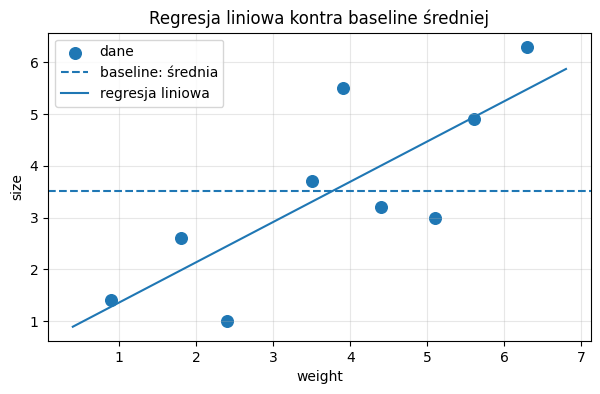

In [16]:
plt.figure(figsize=(7, 4))
plt.scatter(mouse["weight"], mouse["size"], s=70, label="dane")
plt.axhline(y_mean, linestyle="--", label="baseline: średnia")
plt.plot(x_grid, y_grid_pred, label="regresja liniowa")
plt.xlabel("weight")
plt.ylabel("size")
plt.title("Regresja liniowa kontra baseline średniej")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Ręczne ćwiczenie: policz $R^2$ bez modelu

Dane są prawdziwe wartości i predykcje:

| obserwacja | $y_i$ | $\hat y_i$ |
|---:|---:|---:|
| 1 | 10 | 9 |
| 2 | 12 | 13 |
| 3 | 13 | 12 |
| 4 | 15 | 16 |

Kroki:

1. Policz $\bar y$.
2. Policz $\mathrm{TSS}=\sum(y_i-\bar y)^2$.
3. Policz $\mathrm{SSE}=\sum(y_i-\hat y_i)^2$.
4. Policz $R^2=1-\mathrm{SSE}/\mathrm{TSS}$.

Poniżej sprawdzenie w Pythonie.


In [17]:
manual_r2 = pd.DataFrame({
    "y": [10, 12, 13, 15],
    "y_hat": [9, 13, 12, 16],
})
manual_r2["baseline_mean"] = manual_r2["y"].mean()
manual_r2["baseline_sq_error"] = (manual_r2["y"] - manual_r2["baseline_mean"]) ** 2
manual_r2["model_sq_error"] = (manual_r2["y"] - manual_r2["y_hat"]) ** 2

TSS_manual = manual_r2["baseline_sq_error"].sum()
SSE_manual = manual_r2["model_sq_error"].sum()
R2_manual = 1 - SSE_manual / TSS_manual

print(f"mean(y) = {manual_r2['y'].mean():.3f}")
print(f"TSS     = {TSS_manual:.3f}")
print(f"SSE     = {SSE_manual:.3f}")
print(f"R^2     = {R2_manual:.3f}")
manual_r2

mean(y) = 12.500
TSS     = 13.000
SSE     = 4.000
R^2     = 0.692


,y,y_hat,baseline_mean,baseline_sq_error,model_sq_error
0,10,9,12.5,6.25,1
1,12,13,12.5,0.25,1
2,13,12,12.5,0.25,1
3,15,16,12.5,6.25,1


## 10. Test $F$: czy model naprawdę wyjaśnia coś więcej niż sama średnia?

To jest bardziej klasyczna statystyka niż typowy workflow ML, ale bardzo dobrze pomaga zrozumieć:

- czym jest $R^2$,
- jak działają sumy kwadratów,
- oraz co oznacza „wyjaśniona zmienność”.

Pytanie testu:

> Czy model wyjaśnia istotnie więcej zmienności niż prosty baseline przewidujący tylko średnią?

---

Model zerowy przewiduje zawsze:

$$
\hat y_i = \bar y
$$

Natomiast regresja próbuje wykorzystać cechy:

$$
y = b_0 + b_1 x_1 + \dots + b_p x_p
$$

Testujemy hipotezę:

$$
H_0:\beta_1=\beta_2=\dots=\beta_p=0
$$

czyli:

> żadna cecha nie wnosi informacji ponad samą średnią.

---

Rozbijamy całkowitą zmienność danych:

$$
TSS = ESS + RSS
$$

gdzie:

- $TSS$ — całkowita zmienność danych,
- $ESS$ — zmienność wyjaśniona przez model,
- $RSS$ — zmienność niewyjaśniona (residuale).

Interpretacja:

- $ESS$ mówi, ile „chaosu” model potrafił wyjaśnić,
- $RSS$ mówi, ile błędu nadal zostało.

---

Uwzględniamy teraz liczbę parametrów i danych poprzez stopnie swobody:

$$
df_{model}=p
$$

$$
df_{error}=n-p-1
$$

$$
df_{total}=n-1
$$

gdzie:

- $n$ — liczba obserwacji,
- $p$ — liczba cech.

---

Liczymy średnią wyjaśnioną zmienność na parametr:

$$
\mathrm{MSR}=\frac{\mathrm{ESS}}{p}
$$

oraz średni niewyjaśniony błąd:

$$
\mathrm{MSE}=\frac{\mathrm{RSS}}{n-p-1}
$$

---

Statystyka testowa:

$$
F=\frac{\mathrm{MSR}}{\mathrm{MSE}}
=
\frac{\mathrm{ESS}/p}{\mathrm{RSS}/(n-p-1)}
$$

Interpretacja:

- duże $F$ oznacza:
  - model wyjaśnia dużo zmienności,
  - a residuale są względnie małe,
- małe $F$ oznacza:
  - model niewiele poprawia względem średniej.

---

Możemy też zapisać test przez $R^2$:

$$
F = \frac{R^2/p}{(1-R^2)/(n-p-1)}
$$

Dla jednej cechy ($p=1$):

$$
F = \frac{R^2}{1-R^2}(n-2)
$$

---

Na końcu liczymy p-value:

$$
p\text{-value}
=
P(F_{p,n-p-1}\ge F_{observed})
$$

czyli:

> jakie jest prawdopodobieństwo otrzymania tak dużego $F$, jeśli cechy w rzeczywistości nic nie wyjaśniają?

---

Ważna uwaga praktyczna:

> małe p-value nie oznacza automatycznie dobrego modelu predykcyjnego.

Przy bardzo dużej liczbie danych nawet słaby efekt może być „istotny statystycznie”, ale praktycznie mało użyteczny.

## Związek między $R^2$ a odds

W teście $F$ pojawia się wyrażenie:

$$
\frac{R^2}{1-R^2}
$$

które jest matematycznie bardzo podobne do klasycznych odds:

$$
\frac{p}{1-p}
$$

W obu przypadkach mamy schemat:

$$
\frac{x}{1-x}
$$

czyli:

> „część pozytywna” względem „reszty”.

---

Dla prawdopodobieństwa:

$$
\frac{p}{1-p}
$$

oznacza:

$$
\frac{\text{szansa sukcesu}}
{\text{szansa porażki}}
$$

Natomiast dla regresji:

$$
\frac{R^2}{1-R^2}
$$

oznacza:

$$
\frac{\text{wyjaśniona zmienność}}
{\text{niewyjaśniona zmienność}}
$$

czyli:

> ile sygnału model wyjaśnia względem pozostającego szumu.

---

Ponieważ:

$$
R^2=\frac{ESS}{TSS}
$$

oraz:

$$
1-R^2=\frac{RSS}{TSS}
$$

to:

$$
\frac{R^2}{1-R^2}
=
\frac{ESS}{RSS}
$$

Widzimy więc, że test $F$ porównuje:

$$
\frac{\text{signal}}{\text{noise}}
$$

czyli wyjaśnioną strukturę względem niewyjaśnionego błędu.

## Skąd bierze się $\frac{R^2}{1-R^2}$?

Tak — tutaj rzeczywiście pojawia się coś bardzo podobnego do odds ratio.

Mamy:

$$
R^2
=
\frac{\text{wyjaśniona zmienność}}{\text{całkowita zmienność}}
$$

czyli:

$$
R^2
=
\frac{ESS}{TSS}
$$

Natomiast:

$$
1-R^2
=
\frac{RSS}{TSS}
$$

czyli część niewyjaśniona przez model.

---

Gdy podzielimy jedno przez drugie:

$$
\frac{R^2}{1-R^2}
=
\frac{ESS/TSS}{RSS/TSS}
=
\frac{ESS}{RSS}
$$

Dostajemy więc:

$$
\frac{\text{wyjaśniona zmienność}}{\text{niewyjaśniony błąd}}
$$

---

## To naprawdę przypomina odds

W regresji logistycznej:

$$
\mathrm{odds}
=
\frac{p}{1-p}
$$

czyli:

$$
\frac{\text{prawdopodobieństwo sukcesu}}
{\text{prawdopodobieństwo porażki}}
$$

Tutaj analogicznie:

$$
\frac{R^2}{1-R^2}
=
\frac{\text{wyjaśniona część}}
{\text{niewyjaśniona część}}
$$

---

## Intuicja

Jeśli:

$$
R^2 = 0.8
$$

to:

$$
1-R^2 = 0.2
$$

i:

$$
\frac{R^2}{1-R^2}
=
\frac{0.8}{0.2}
=
4
$$

Interpretacja:

> model wyjaśnia około 4 razy więcej zmienności niż pozostawia niewyjaśnionego błędu.

---

## Bardzo ciekawa intuicja dydaktyczna

Można studentom powiedzieć:

- odds:
  - sukces vs porażka,
- $\frac{R^2}{1-R^2}$:
  - wyjaśniona struktura vs niewyjaśniony chaos.

To nie jest formalnie odds ratio z regresji logistycznej, ale algebraicznie i intuicyjnie jest bardzo podobne.

## Dlaczego samo $\frac{R^2}{1-R^2}$ nie wystarcza?

W teście $F$ nie bierzemy tylko:

$$
\frac{R^2}{1-R^2}
$$

ale:

$$
F
=
\frac{R^2/p}{(1-R^2)/(n-p-1)}
$$

czyli korygujemy wynik o:

- liczbę cech $p$,
- liczbę obserwacji $n$,
- liczbę stopni swobody w residualach.

Dla jednej cechy:

$$
F
=
\frac{R^2}{1-R^2}(n-2)
$$

To pokazuje ważną rzecz:

> ten sam poziom $R^2$ może dawać różną statystyczną siłę dowodu w zależności od liczby obserwacji.

Przy dużym $n$ nawet umiarkowane $R^2$ może dawać duże $F$ i małe p-value.

Dlatego:

> małe p-value nie znaczy automatycznie, że model jest dobry predykcyjnie.

In [18]:
from scipy.stats import f as f_dist

n = len(y_arr)
p = 1  # liczba cech, bez interceptu
TSS = ss["TSS_total_variation"]
SSR = ss["SSR_explained_variation"]
SSE_model = ss["SSE_unexplained_error"]
R2 = ss["R2_1_minus_SSE_over_TSS"]

df_model = p
df_error = n - p - 1
df_total = n - 1

MSR = SSR / df_model
MSE_resid = SSE_model / df_error
F_stat = MSR / MSE_resid
F_from_R2 = (R2 / p) / ((1 - R2) / (n - p - 1))
p_value = f_dist.sf(F_stat, df_model, df_error)

anova = pd.DataFrame({
    "source": ["model / explained", "residual / unexplained", "total"],
    "SS": [SSR, SSE_model, TSS],
    "df": [df_model, df_error, df_total],
    "MS": [MSR, MSE_resid, np.nan],
})

print(f"F z tabeli ANOVA = {F_stat:.6f}")
print(f"F z R^2          = {F_from_R2:.6f}")
print(f"p-value          = {p_value:.6f}")
anova

F z tabeli ANOVA = 11.101267
F z R^2          = 11.101267
p-value          = 0.012559


,source,SS,df,MS
0,model / explained,15.730124,1,15.730124
1,residual / unexplained,9.918765,7,1.416966
2,total,25.648889,8,NaN


### Jak opowiadać $F$ na wykładzie?

- $\mathrm{MSR}$ to „średnia ilość zmienności wyjaśnionej przez jedną cechę”.
- $\mathrm{MSE}$ to „średnia ilość niewyjaśnionego błędu na jeden stopień swobody”.
- $F$ jest ilorazem: **sygnał modelu / szum resztowy**.
- Duże $F$ sugeruje, że model poprawia baseline bardziej, niż spodziewalibyśmy się przypadkiem.
- Dla jednej cechy test $F$ i test t nachylenia mówią w praktyce to samo: $F=t^2$.

W kursie ML warto podkreślić rozróżnienie:

> Test $F$ pyta o istotność statystyczną w danych treningowych. Train/test i CV pytają o generalizację na nowych danych.


## 11. Adjusted $R^2$: kara za dodawanie cech

Treningowe $R^2$ w regresji liniowej z interceptem zwykle **nie spada**, gdy dokładamy kolejne cechy. Nawet losowa cecha może minimalnie poprawić dopasowanie na treningu.

Dlatego w statystyce często pokazuje się adjusted $R^2$:

$$\bar R^2 = 1 - (1-R^2)\frac{n-1}{n-p-1}$$

Równoważnie:

$$\bar R^2 = 1 - \frac{\mathrm{SSE}/(n-p-1)}{\mathrm{TSS}/(n-1)}$$

Intuicja:

> Zwykłe $R^2$ pyta: „ile błędu zredukowaliśmy?”. Adjusted $R^2$ pyta: „czy redukcja błędu jest warta liczby użytych cech?”.

Adjusted $R^2$ nadal nie zastępuje walidacji. To jest korekta in-sample, a nie prawdziwy test generalizacji.


In [19]:
def adjusted_r2_score(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

adj_R2 = adjusted_r2_score(R2, n, p)

pd.DataFrame({
    "metric": ["R2", "adjusted_R2"],
    "value": [R2, adj_R2],
})

,metric,value
0,R2,0.613287
1,adjusted_R2,0.558042


## 12. Perspektywa algebry liniowej: projekcja

Dla wielu cech model zapisujemy macierzowo:

$$\hat y = X\beta$$

W prostej regresji z interceptem macierz $X$ ma dwie kolumny:

$$X = \begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix}$$

Rozwiązanie najmniejszych kwadratów można zapisać jako:

$$\hat\beta = (X^TX)^{-1}X^Ty$$

Interpretacja geometryczna:

> Predykcje $\hat y$ są projekcją wektora $y$ na przestrzeń rozpiętą przez kolumny macierzy $X$.

To jest bardzo dobry most do PCA, SVM i regularizacji.


In [20]:
X_design = np.column_stack([np.ones(len(x)), x])
beta_closed_form = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_arr

print("beta = [b0, b1]")
print(beta_closed_form)


beta = [b0, b1]
[0.581 0.778]


## 13. Train/test: czy model działa na nowych danych?

Na bardzo małym zbiorze łatwo zrozumieć ideę, ale w ML pytanie brzmi:

> Czy model działa na obserwacjach, których nie widział podczas uczenia?

Dlatego przechodzimy na większy syntetyczny przykład i robimy podział:

- `train` — dane do nauczenia parametrów,
- `test` — dane do oceny generalizacji.


In [21]:
rng = np.random.default_rng(42)
X_big = rng.uniform(0, 10, size=160)
noise = rng.normal(0, 2.0, size=160)
y_big = 2.5 * X_big + 4.0 + noise

big = pd.DataFrame({"x": X_big, "y": y_big})

X_train, X_test, y_train, y_test = train_test_split(
    big[["x"]], big["y"], test_size=0.25, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_test_metrics = pd.DataFrame([
    regression_report(y_train, y_train_pred, "train"),
    regression_report(y_test, y_test_pred, "test"),
])

print(f"Parametry modelu: y_hat = {model.intercept_:.3f} + {model.coef_[0]:.3f} * x")
train_test_metrics


Parametry modelu: y_hat = 3.562 + 2.617 * x


,model,MAE,MSE,RMSE,R2
0,train,1.636687,4.013129,2.003279,0.921891
1,test,1.496454,4.231590,2.057083,0.913688


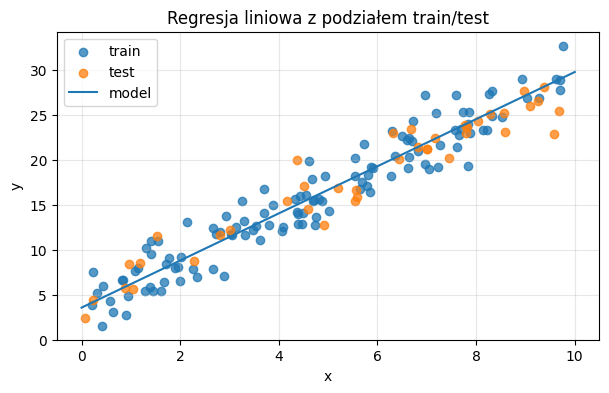

In [22]:
x_grid_big = np.linspace(0, 10, 200)
y_grid_big = model.predict(pd.DataFrame({"x": x_grid_big}))

plt.figure(figsize=(7, 4))
plt.scatter(X_train["x"], y_train, label="train", alpha=0.75)
plt.scatter(X_test["x"], y_test, label="test", alpha=0.75)
plt.plot(x_grid_big, y_grid_big, label="model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regresja liniowa z podziałem train/test")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 14. Cross-validation: stabilniejsza ocena

Pojedynczy train/test split może być przypadkowo łatwy albo trudny.

Cross-validation powtarza eksperyment na kilku podziałach danych. Dla regresji często raportujemy średni RMSE i odchylenie standardowe.


In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
neg_mse_scores = cross_val_score(
    LinearRegression(), big[["x"]], big["y"],
    scoring="neg_mean_squared_error",
    cv=cv,
)
rmse_scores = np.sqrt(-neg_mse_scores)

print("RMSE w foldach:", np.round(rmse_scores, 3))
print(f"Średni RMSE CV = {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")


RMSE w foldach: [1.862 2.152 2.22  2.173 1.816]
Średni RMSE CV = 2.045 ± 0.170


## 15. Fitowanie, underfitting i overfitting

Słowo `.fit()` oznacza: znajdź parametry modelu na danych treningowych.

Ale dobre dopasowanie do treningu to jeszcze nie sukces. Możemy mieć trzy sytuacje:

### Underfitting

Model jest za prosty. Nie łapie struktury danych.

Objaw:

- treningowe metryki są słabe,
- testowe metryki też są słabe.

### Dobry fit

Model łapie główną strukturę, ale nie próbuje zapamiętać szumu.

Objaw:

- treningowe metryki są dobre,
- testowe metryki są podobnie dobre.

### Overfitting

Model jest zbyt elastyczny. Uczy się przypadkowego szumu z treningu.

Objaw:

- treningowe metryki są świetne,
- testowe metryki są wyraźnie gorsze.

Poniżej przykład z regresją wielomianową: formalnie nadal używamy `LinearRegression`, ale na cechach $x, x^2, x^3, \dots$.


In [24]:
rng = np.random.default_rng(42)

X_curve = np.sort(rng.uniform(0, 1, 60))
y_curve = np.cos(1.5 * np.pi * X_curve) + rng.normal(0, 0.12, size=len(X_curve))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_curve.reshape(-1, 1), y_curve,
    test_size=0.40,
    random_state=42,
)

degrees = [1, 3, 6, 15]
fit_rows = []
fitted_models = {}

for degree in degrees:
    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    poly_model.fit(Xc_train, yc_train)
    fitted_models[degree] = poly_model

    pred_train = poly_model.predict(Xc_train)
    pred_test = poly_model.predict(Xc_test)

    fit_rows.append({
        "degree": degree,
        "train_R2": r2_score(yc_train, pred_train),
        "test_R2": r2_score(yc_test, pred_test),
        "train_RMSE": np.sqrt(mean_squared_error(yc_train, pred_train)),
        "test_RMSE": np.sqrt(mean_squared_error(yc_test, pred_test)),
    })

fit_table = pd.DataFrame(fit_rows)
fit_table

,degree,train_R2,test_R2,train_RMSE,test_RMSE
0,1,0.636452,0.654617,0.385792,0.438902
1,3,0.980215,0.973084,0.090000,0.122524
2,6,0.983822,0.979589,0.081384,0.106696
3,15,0.991898,0.973043,0.057594,0.122617


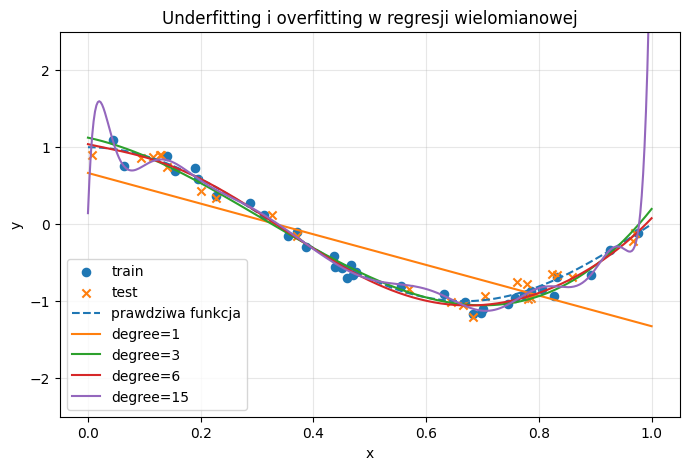

In [25]:
x_plot = np.linspace(0, 1, 400).reshape(-1, 1)
true_curve = np.cos(1.5 * np.pi * x_plot.ravel())

plt.figure(figsize=(8, 5))
plt.scatter(Xc_train.ravel(), yc_train, s=35, label="train")
plt.scatter(Xc_test.ravel(), yc_test, s=35, marker="x", label="test")
plt.plot(x_plot.ravel(), true_curve, linestyle="--", label="prawdziwa funkcja")

for degree, poly_model in fitted_models.items():
    plt.plot(x_plot.ravel(), poly_model.predict(x_plot), label=f"degree={degree}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Underfitting i overfitting w regresji wielomianowej")
plt.ylim(-2.5, 2.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

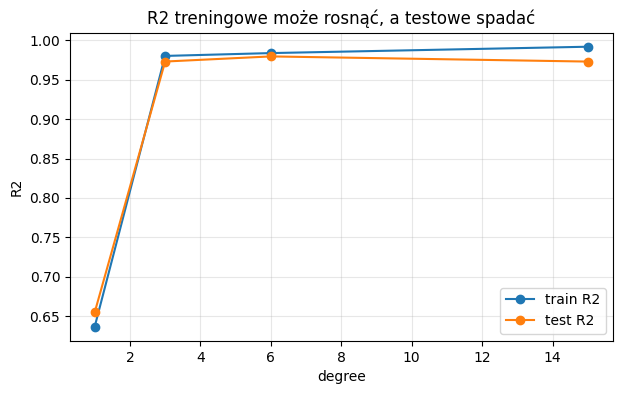

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(fit_table["degree"], fit_table["train_R2"], marker="o", label="train R2")
plt.plot(fit_table["degree"], fit_table["test_R2"], marker="o", label="test R2")
plt.xlabel("degree")
plt.ylabel("R2")
plt.title("R2 treningowe może rosnąć, a testowe spadać")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Jak czytać wyniki:

- `degree=1`: zbyt prosty model — underfitting.
- `degree=3` lub `degree=6`: model łapie strukturę — lepszy kompromis.
- `degree=15`: bardzo elastyczny model — treningowo może wyglądać dobrze, ale test/CV ostrzega przed overfittingiem.

To jest pomost do kolejnych tematów kursu:

- regularizacja Ridge/Lasso ogranicza nadmierną elastyczność,
- cross-validation pomaga wybrać stopień wielomianu lub siłę regularyzacji,
- testowe $R^2$ jest ważniejsze od treningowego $R^2$.


In [27]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for degree in degrees:
    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    neg_mse = cross_val_score(
        poly_model,
        X_curve.reshape(-1, 1),
        y_curve,
        scoring="neg_mean_squared_error",
        cv=cv,
    )
    rmse = np.sqrt(-neg_mse)
    cv_rows.append({
        "degree": degree,
        "CV_RMSE_mean": rmse.mean(),
        "CV_RMSE_std": rmse.std(),
    })

pd.DataFrame(cv_rows)

,degree,CV_RMSE_mean,CV_RMSE_std
0,1,0.413798,0.019864
1,3,0.107010,0.016494
2,6,0.099305,0.008789
3,15,0.452495,0.714047


## 16. Analiza reszt: czy w błędach została struktura?

Po dopasowaniu modelu patrzymy na reszty:

$$e_i = y_i - \hat y_i$$

Dobre pytania diagnostyczne:

1. Czy reszty są mniej więcej wokół zera?
2. Czy model systematycznie zaniża albo zawyża predykcje?
3. Czy wariancja reszt rośnie dla większych predykcji?
4. Czy są punkty odstające?
5. Czy w resztach widać krzywiznę, czyli sygnał, że model liniowy jest zbyt prosty?


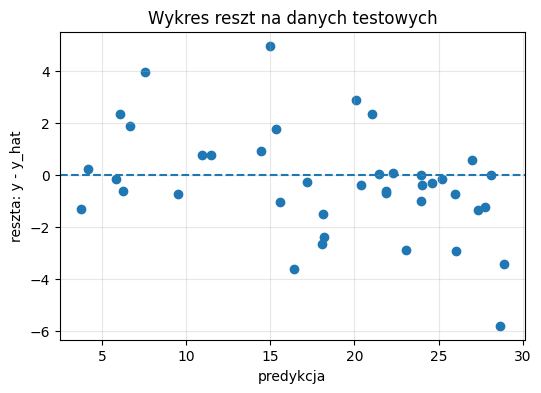

In [28]:
residuals_test = y_test - y_test_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred, residuals_test)
plt.axhline(0, linestyle="--")
plt.xlabel("predykcja")
plt.ylabel("reszta: y - y_hat")
plt.title("Wykres reszt na danych testowych")
plt.grid(alpha=0.3)
plt.show()


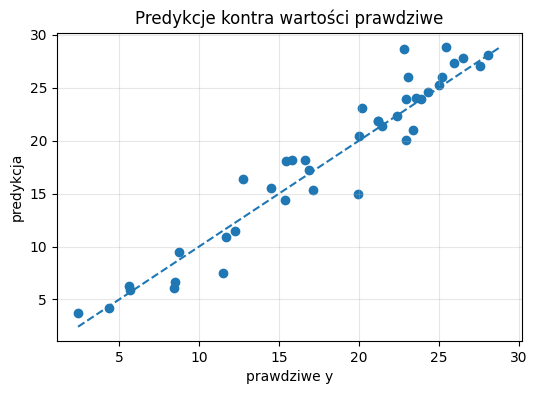

In [29]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_test_pred)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("prawdziwe y")
plt.ylabel("predykcja")
plt.title("Predykcje kontra wartości prawdziwe")
plt.grid(alpha=0.3)
plt.show()


## 17. Outlier i leverage: jeden punkt może zmienić prostą

Regresja liniowa minimalizuje kwadraty błędów, więc duże błędy mają duży wpływ na wynik.

Punkt odstający może być szczególnie wpływowy, gdy jest daleko w osi $x$ — wtedy mówimy o dużym **leverage**.


Bez outliera:
  y_hat = 0.581 + 0.778 * weight
Z outlierem:
  y_hat = 2.220 + 0.252 * weight


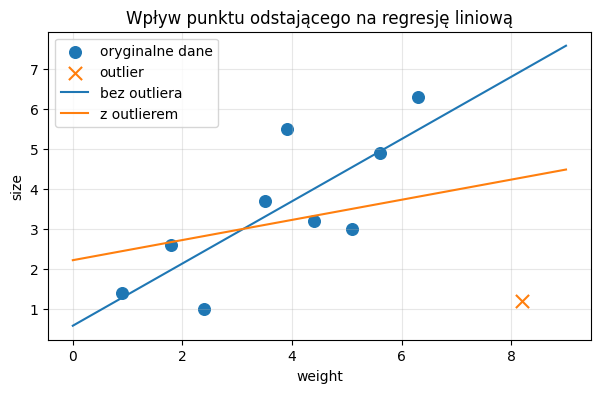

In [30]:
mouse_outlier = pd.concat([
    mouse,
    pd.DataFrame({"weight": [8.2], "size": [1.2]})
], ignore_index=True)

lin_clean = LinearRegression().fit(mouse[["weight"]], mouse["size"])
lin_outlier = LinearRegression().fit(mouse_outlier[["weight"]], mouse_outlier["size"])

x_grid_out = np.linspace(0, 9, 200)
clean_line = lin_clean.predict(pd.DataFrame({"weight": x_grid_out}))
outlier_line = lin_outlier.predict(pd.DataFrame({"weight": x_grid_out}))

print("Bez outliera:")
print(f"  y_hat = {lin_clean.intercept_:.3f} + {lin_clean.coef_[0]:.3f} * weight")
print("Z outlierem:")
print(f"  y_hat = {lin_outlier.intercept_:.3f} + {lin_outlier.coef_[0]:.3f} * weight")

plt.figure(figsize=(7, 4))
plt.scatter(mouse["weight"], mouse["size"], s=70, label="oryginalne dane")
plt.scatter([8.2], [1.2], s=90, marker="x", label="outlier")
plt.plot(x_grid_out, clean_line, label="bez outliera")
plt.plot(x_grid_out, outlier_line, label="z outlierem")
plt.xlabel("weight")
plt.ylabel("size")
plt.title("Wpływ punktu odstającego na regresję liniową")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 18. Pułapka $R^2$: dodawanie losowych cech może poprawić trening

Jeśli dodamy kolejne cechy do regresji liniowej, model ma więcej swobody. Na danych treningowych $R^2$ zwykle wzrośnie albo pozostanie takie samo.

Ale to nie oznacza, że model lepiej generalizuje.

Poniżej dodamy wiele losowych cech, które nie niosą informacji o $y$. To dobry przykład do dyskusji:

> Czy większe treningowe $R^2$ zawsze oznacza lepszy model?

Odpowiedź: nie. Patrzymy na test/CV, a nie tylko na trening.


In [31]:
rng = np.random.default_rng(7)
n = 120
x_signal = rng.normal(size=n)
y_signal = 3.0 * x_signal + rng.normal(scale=1.2, size=n)
noise_features = rng.normal(size=(n, 20))

X_one = pd.DataFrame({"x_signal": x_signal})
X_many = pd.DataFrame(noise_features, columns=[f"noise_{j}" for j in range(noise_features.shape[1])])
X_many.insert(0, "x_signal", x_signal)

X1_train, X1_test, ym_train, ym_test = train_test_split(X_one, y_signal, test_size=0.35, random_state=42)
Xm_train, Xm_test, _, _ = train_test_split(X_many, y_signal, test_size=0.35, random_state=42)

m_one = LinearRegression().fit(X1_train, ym_train)
m_many = LinearRegression().fit(Xm_train, ym_train)

comparison = pd.DataFrame([
    regression_report(ym_train, m_one.predict(X1_train), "1 cecha: train"),
    regression_report(ym_test, m_one.predict(X1_test), "1 cecha: test"),
    regression_report(ym_train, m_many.predict(Xm_train), "1 sygnał + 20 szumów: train"),
    regression_report(ym_test, m_many.predict(Xm_test), "1 sygnał + 20 szumów: test"),
])
comparison


,model,MAE,MSE,RMSE,R2
0,1 cecha: train,0.962891,1.349592,1.161719,0.845495
1,1 cecha: test,0.819305,1.089476,1.043780,0.842857
2,1 sygnał + 20 szumów: train,0.853844,1.100864,1.049220,0.873970
3,1 sygnał + 20 szumów: test,0.804223,0.926522,0.962560,0.866361


In [32]:
def adjusted_r2_for_table(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

r2_one_train = r2_score(ym_train, m_one.predict(X1_train))
r2_many_train = r2_score(ym_train, m_many.predict(Xm_train))

pd.DataFrame({
    "model": ["1 cecha", "1 sygnał + 20 szumów"],
    "train_R2": [r2_one_train, r2_many_train],
    "train_adjusted_R2": [
        adjusted_r2_for_table(r2_one_train, len(ym_train), X1_train.shape[1]),
        adjusted_r2_for_table(r2_many_train, len(ym_train), Xm_train.shape[1]),
    ],
})


,model,train_R2,train_adjusted_R2
0,1 cecha,0.845495,0.843462
1,1 sygnał + 20 szumów,0.873970,0.826709


## 19. Nieliniowość: prosta nie zawsze wystarcza

Jeśli zależność jest krzywoliniowa, zwykła prosta może mieć słaby wynik, a wykres reszt pokaże strukturę.

Ważne pojęcie:

> Model może być nieliniowy względem cechy $x$, ale nadal liniowy względem parametrów.

Przykład:

$$\hat y = b_0 + b_1x + b_2x^2$$

To jest regresja wielomianowa, ale nadal model liniowy względem parametrów $b_0,b_1,b_2$.


In [33]:
rng = np.random.default_rng(123)
X_curve = rng.uniform(-3, 3, size=180)
y_curve = 1.5 * X_curve**2 + rng.normal(0, 1.6, size=180)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_curve.reshape(-1, 1), y_curve, test_size=0.25, random_state=42
)

linear_bad = LinearRegression().fit(Xc_train, yc_train)
poly2 = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly2.fit(Xc_train, yc_train)

curve_metrics = pd.DataFrame([
    regression_report(yc_test, linear_bad.predict(Xc_test), "prosta"),
    regression_report(yc_test, poly2.predict(Xc_test), "wielomian stopnia 2"),
])
curve_metrics


,model,MAE,MSE,RMSE,R2
0,prosta,3.697247,19.993367,4.471394,-0.148832
1,wielomian stopnia 2,1.200509,2.429551,1.558702,0.860396


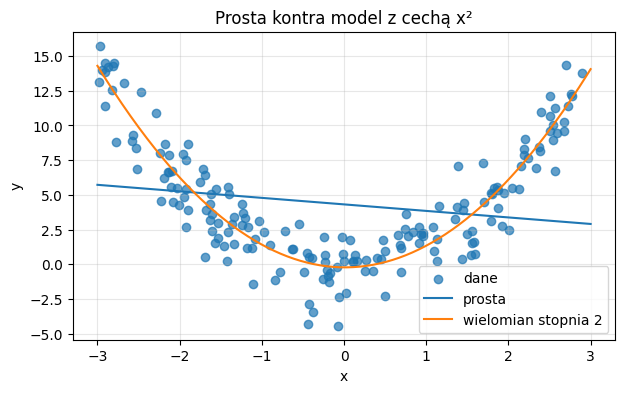

In [34]:
x_grid_curve = np.linspace(-3, 3, 300).reshape(-1, 1)

plt.figure(figsize=(7, 4))
plt.scatter(X_curve, y_curve, alpha=0.7, label="dane")
plt.plot(x_grid_curve.ravel(), linear_bad.predict(x_grid_curve), label="prosta")
plt.plot(x_grid_curve.ravel(), poly2.predict(x_grid_curve), label="wielomian stopnia 2")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Prosta kontra model z cechą x²")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 20. Ekstrapolacja: predykcja poza zakresem danych

Regresja liniowa zawsze przedłuża prostą. To bywa niebezpieczne.

Jeśli dane treningowe obejmują `weight` od 0.9 do 6.3, predykcja dla `weight = 7` może być umiarkowanie rozsądna, ale dla `weight = 100` jest tylko mechanicznym przedłużeniem wzoru.

Na wykładzie warto powiedzieć:

> Model nie wie, gdzie kończy się sensowny świat. My musimy to kontrolować.


In [35]:
new_points = pd.DataFrame({"weight": [2.0, 4.0, 7.0, 100.0]})
new_points["prediction"] = lin.predict(new_points)
new_points["comment"] = [
    "wewnątrz zakresu",
    "wewnątrz zakresu",
    "lekko poza zakresem",
    "daleko poza zakresem: ekstrapolacja",
]
new_points


,weight,prediction,comment
0,2.0,2.136962,wewnątrz zakresu
1,4.0,3.692603,wewnątrz zakresu
2,7.0,6.026064,lekko poza zakresem
3,100.0,78.363372,daleko poza zakresem: ekstrapolacja


## 21. Co zakłada regresja liniowa?

W praktyce warto rozdzielić dwa cele.

### Gdy celem jest predykcja ML

Najważniejsze pytanie brzmi: czy model dobrze generalizuje na nowych danych?

Sprawdzamy więc:

- train/test lub cross-validation,
- metryki regresyjne,
- wykresy reszt,
- stabilność względem outlierów,
- sensowność predykcji poza zakresem danych.

### Gdy celem jest wnioskowanie statystyczne

Wtedy ważniejsze są założenia:

- zależność jest liniowa względem parametrów,
- obserwacje są niezależne,
- reszty mają podobną wariancję,
- nie ma silnych outlierów wpływowych,
- przy testach istotności często zakładamy przybliżoną normalność reszt,
- w wielu cechach nie ma idealnej współliniowości.

Nie chodzi o to, żeby student zapamiętał listę na pamięć. Chodzi o pytanie:

> Czy błędy modelu wyglądają jak losowy szum, czy jak informacja, której model nie umie opisać?


## 22. Mini-zadania na zajęcia

### Zadanie A — ręczne liczenie SSE

Dane są punkty:

| x | y |
|---|---|
| 1 | 2 |
| 2 | 3 |
| 3 | 5 |

Porównaj dwie proste:

$$\hat y = x + 1$$

oraz

$$\hat y = 1.5x + 0.2$$

Policz dla każdej:

1. predykcje $\hat y$,
2. reszty $e_i = y_i - \hat y_i$,
3. kwadraty reszt,
4. SSE.

Która prosta jest lepsza według SSE?

---

### Zadanie B — baseline, TSS, SSE i $R^2$

Dla danych:

| y | predykcja modelu |
|---|---|
| 10 | 9 |
| 12 | 13 |
| 13 | 12 |
| 15 | 16 |

Policz:

1. średnią $\bar y$,
2. TSS względem średniej,
3. SSE modelu,
4. $R^2$.

Pytanie interpretacyjne: czy model jest lepszy od przewidywania średniej?

---

### Zadanie C — tabela ANOVA i statystyka $F$

Załóżmy, że dla regresji z jedną cechą mamy:

- $n=12$,
- $\mathrm{TSS}=240$,
- $\mathrm{SSE}=90$,
- $p=1$.

Policz:

1. $\mathrm{SSR}=\mathrm{TSS}-\mathrm{SSE}$,
2. $R^2$,
3. $df_{model}$, $df_{error}$, $df_{total}$,
4. $\mathrm{MSR}$ i $\mathrm{MSE}$,
5. statystykę $F$.

Dodatkowo sprawdź, czy wynik $F$ zgadza się ze wzorem:

$$F=\frac{R^2/p}{(1-R^2)/(n-p-1)}$$

---

### Zadanie D — interpretacja współczynnika

Model ma postać:

$$\widehat{\text{cena mieszkania}} = 120000 + 9500 \cdot \text{metry}$$

Co oznacza współczynnik 9500? Czy intercept 120000 ma zawsze sens praktyczny?

---

### Zadanie E — analiza reszt

Dostajesz wykres reszt, na którym reszty tworzą kształt litery U. Co to sugeruje?

---

### Zadanie F — underfitting kontra overfitting

Model A ma treningowe $R^2=0.92$ i testowe $R^2=0.41$.
Model B ma treningowe $R^2=0.78$ i testowe $R^2=0.74$.

Który model wolisz wdrożyć i dlaczego?

---

### Zadanie G — ujemne $R^2$

Na zbiorze testowym model uzyskał $R^2=-0.35$.

1. Co to znaczy względem baseline’u średniej?
2. Czy taki wynik może się zdarzyć mimo poprawnego działania kodu?
3. Co sprawdzić jako pierwsze: dane, preprocessing, rozkład train/test czy formę modelu?

---

### Zadanie H — dyskusja: istotność statystyczna a predykcja

Model ma p-value z testu $F$ równe 0.0001, ale testowe $R^2=0.08$.

Pytania:

1. Czy model jest statystycznie istotny?
2. Czy model jest predykcyjnie mocny?
3. Jak można wyjaśnić tę pozorną sprzeczność?


## 23. Zadanie GeoGebra: regresja jako szukanie minimum, $R^2$ i $F$

### Część 1 — suwaki i minimum SSE

1. Wstaw listę punktów:

```text
L = {(0.9,1.4), (1.8,2.6), (2.4,1.0), (3.5,3.7), (3.9,5.5), (4.4,3.2), (5.1,3.0), (5.6,4.9), (6.3,6.3)}
```

2. Dodaj suwaki `a` i `b`.
3. Zdefiniuj prostą ręczną:

```text
f(x) = a*x + b
```

4. Policz błąd ręcznej prostej:

```text
SSE_manual = SumSquaredErrors(L, f)
```

5. Dodaj automatyczną prostą regresji:

```text
g(x) = FitLine(L)
SSE_fit = SumSquaredErrors(L, g)
```

6. Zadanie dla studentów:

> Poruszaj suwakami `a` i `b`, aż `SSE_manual` będzie jak najmniejsze. Czy udało Ci się zbliżyć do `SSE_fit`?

### Część 2 — baseline średniej i $R^2$

7. Zdefiniuj baseline przewidujący średnią:

```text
ybar = Mean({1.4,2.6,1.0,3.7,5.5,3.2,3.0,4.9,6.3})
m(x) = ybar
SSE_mean = SumSquaredErrors(L, m)
```

8. Policz $R^2$:

```text
R2 = 1 - SSE_fit / SSE_mean
```

Pytania:

- Co oznacza `SSE_mean`?
- Co oznacza `SSE_fit`?
- Co znaczy, że $R^2$ jest bliskie 1?
- Co znaczyłoby $R^2$ bliskie 0?

### Część 3 — statystyka $F$

Dla jednej cechy mamy:

```text
n = 9
p = 1
Fstat = ((SSE_mean - SSE_fit) / p) / (SSE_fit / (n - p - 1))
```

Pytanie do dyskusji:

> Dlaczego w liczniku jest poprawa względem średniej, a w mianowniku błąd, który pozostał po dopasowaniu prostej?

### Część 4 — refleksja

- Czy najlepsza prosta musi przechodzić przez większość punktów?
- Czy można mieć małe SSE, ale słabą interpretowalność poza zakresem danych?
- Co stanie się z predykcją dla `weight = 100`?

Odpowiedź do pierwszego pytania: nie. Najlepsza prosta minimalizuje globalny błąd, a nie liczbę trafionych punktów.


## 24. Most do kolejnych wykładów

Regresja liniowa przygotowuje grunt pod kilka kolejnych tematów:

- **logistic regression**: liniowy wynik zamieniamy na prawdopodobieństwo klasy,
- **Ridge/Lasso/Elastic Net**: do SSE dodajemy karę za duże lub liczne współczynniki,
- **LDA/QDA/Naive Bayes**: wchodzimy w modele probabilistyczne,
- **PCA**: wraca interpretacja projekcji i przestrzeni liniowych,
- **SVM**: prosta/hiperpłaszczyzna pojawia się jako granica z marginesem,
- **boosting**: modelowanie błędów staje się centralną ideą.

Najważniejsze zdanie do zapamiętania:

> Model liniowy jest prosty, ale nie banalny: ma jasną funkcję straty, dobrą interpretację geometryczną i stanowi fundament wielu późniejszych algorytmów.


## 25. Źródła i inspiracje

- StatQuest — *Linear Regression, Clearly Explained!!!* jako inspiracja narracyjna: najpierw najmniejsze kwadraty, potem $R^2$ i istotność modelu.
- Penn State STAT 462 — interpretacja $R^2$ przez $\mathrm{SSR}/\mathrm{SST}$ oraz $1-\mathrm{SSE}/\mathrm{SST}$.
- The Book of Statistical Proofs — relacja między statystyką $F$ a $R^2$.
- scikit-learn — dokumentacja `r2_score`, w tym fakt, że $R^2$ może być ujemne na danych testowych.
- scikit-learn — przykład underfittingu i overfittingu przez regresję wielomianową.


## Bonus: t-test i ANOVA jako modele liniowe — przykład z ekspresją genu

To jest krótki most do kolejnych zajęć o modelach liniowych. Ta sama logika, której użyliśmy dla regresji liniowej, działa też dla porównywania średnich grupowych.

Pytanie:

> Czy ekspresja genu różni się między myszami `Control` i `Mutant`?

Model zerowy przewiduje jedną średnią ogólną. Model dopasowany przewiduje osobną średnią dla każdej grupy. Porównanie tych modeli przez $SSE$ i test $F$ daje odpowiednik t-testu.

In [15]:
from scipy.stats import f as f_dist, ttest_ind

gene = pd.DataFrame({
    "genotype": ["Control"] * 4 + ["Mutant"] * 4,
    "gene_expression": [1.7, 2.1, 2.3, 2.7, 3.1, 3.4, 3.7, 4.2],
})

y_gene = gene["gene_expression"].to_numpy()
X_mean_gene = np.ones((len(gene), 1))
X_group_gene = pd.get_dummies(gene["genotype"])[["Control", "Mutant"]].astype(float).to_numpy()

beta_mean = np.linalg.lstsq(X_mean_gene, y_gene, rcond=None)[0]
beta_group = np.linalg.lstsq(X_group_gene, y_gene, rcond=None)[0]

yhat_mean = X_mean_gene @ beta_mean
yhat_group = X_group_gene @ beta_group

SSE_mean_gene = np.sum((y_gene - yhat_mean) ** 2)
SSE_fit_gene = np.sum((y_gene - yhat_group) ** 2)

n_gene = len(y_gene)
p_mean_gene = 1
p_fit_gene = 2

F_gene = ((SSE_mean_gene - SSE_fit_gene) / (p_fit_gene - p_mean_gene)) / (SSE_fit_gene / (n_gene - p_fit_gene))
p_gene = f_dist.sf(F_gene, p_fit_gene - p_mean_gene, n_gene - p_fit_gene)

pd.DataFrame({
    "quantity": ["overall mean", "Control mean", "Mutant mean", "SSE_mean", "SSE_fit", "F", "p_value"],
    "value": [beta_mean[0], beta_group[0], beta_group[1], SSE_mean_gene, SSE_fit_gene, F_gene, p_gene]
})

,quantity,value
0,overall mean,2.900000
1,Control mean,2.200000
2,Mutant mean,3.600000
3,SSE_mean,5.100000
4,SSE_fit,1.180000
5,F,19.932203
6,p_value,0.004262


In [16]:
control = gene.loc[gene["genotype"] == "Control", "gene_expression"]
mutant = gene.loc[gene["genotype"] == "Mutant", "gene_expression"]
t_stat, p_t = ttest_ind(control, mutant, equal_var=True)

pd.DataFrame({
    "test": ["F from linear model", "t-test"],
    "statistic": [F_gene, t_stat],
    "t_squared": [np.nan, t_stat**2],
    "p_value": [p_gene, p_t],
})

,test,statistic,t_squared,p_value
0,F from linear model,19.932203,NaN,0.004262
1,t-test,-4.464550,19.932203,0.004262


Wniosek do powiedzenia na głos:

> Przy dwóch grupach test $F$ z modelu liniowego daje to samo p-value, co klasyczny t-test z założeniem równej wariancji. Dla wielu grup ten sam schemat staje się ANOVA. Dla zmiennych ciągłych wracamy do regresji. Różne testy, jeden język: design matrix + suma kwadratów + porównanie modeli.

Pełne rozwinięcie tego przykładu znajduje się w notebooku `09_statquest_glm_gene_expression_design_matrix.ipynb`.